In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("reviews.csv") 

In [3]:
df.shape

(1000, 2)

In [4]:
df.sample(5)

,Description,Is_Response
432,What a beautiful hotel and AWSOME location. Ri...,not happy
545,I've stayed at this hotel a couple of times. I...,happy
834,Had a fantastic stay at this hotel...They were...,happy
459,I have stayed at this property several times. ...,not happy
638,"Great accommodation, very clean, walking dista...",happy


In [5]:
# Remove all rows with null values
df.dropna(axis=0, inplace=True)

In [6]:
df.shape

(1000, 2)

In [7]:
# Change Is_Response to 0 for not happy and 1 for happy
df['Is_Response'] = df['Is_Response'].replace(['happy', 'not happy'],  ['1', '0'])

In [8]:
df.sample(5)

,Description,Is_Response
668,We arrived at this hotel by mistake. I had mad...,1
16,Priceline sent us to this hotel after acceptin...,0
571,Very clean modern hotel with a perfect locatio...,1
822,Loved the hotel and its location! We're a fami...,1
270,I have stayed at other Four Points Sheratons w...,0


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression

In [10]:
X = df['Description']
y = df['Is_Response']

In [11]:
# tf-idf means term-frequency times inverse document-frequency. 
tfidf = TfidfVectorizer(ngram_range=(1,1), stop_words='english')
tfidf.fit(X)
features = tfidf.transform(X)

In [12]:
features.shape

(1000, 8212)

In [13]:
features[:10,500:510]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1 stored elements and shape (10, 10)>

In [14]:
X_train, X_test, y_train, y_test = train_test_split(features,y,test_size=0.2,random_state=20)

In [15]:
clf = LogisticRegression().fit(X_train,y_train)

In [16]:
### Train accuracy
clf.score(X_train,y_train)

0.8925

In [17]:
y_pred = clf.predict(X_test)
print("Accuracy Score:",clf.score(X_test,y_test))  

Accuracy Score: 0.79


In [18]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[ 28  42]
 [  0 130]]


In [19]:
from sklearn.metrics import classification_report
print( classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.40      0.57        70
           1       0.76      1.00      0.86       130

    accuracy                           0.79       200
   macro avg       0.88      0.70      0.72       200
weighted avg       0.84      0.79      0.76       200



Text(0.5, 23.52222222222222, 'Predicted')

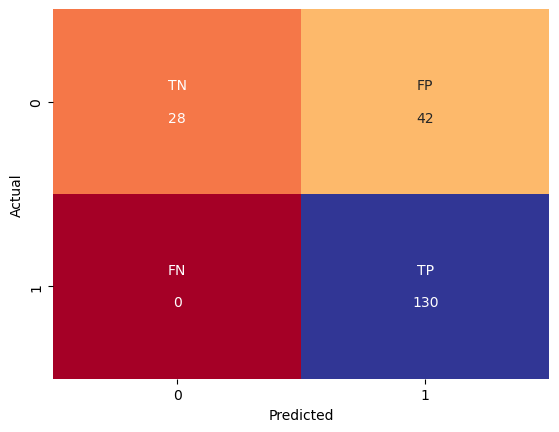

In [20]:
group_counts = [f"{value:0.0f}" for value in  cm.flatten()]
group_names = ['TN','FP', 'FN','TP']
labels = [f"{v1}\n\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.array(labels).reshape(2,2)
ax = sns.heatmap(cm, annot=labels, fmt="", cmap='RdYlBu',cbar=False)
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")

### Predict for new data

In [21]:
# tfidf.vocabulary_

In [22]:
# Predict whether the given review is positive or negative 
docs = ["This is very good",
        "Room service is NOT bad",
        "Food was awesome"]
# Tfidf
features = tfidf.transform(docs)
print(features.shape)
print(clf.predict(features))

(3, 8212)
['1' '0' '1']


## Text classification using BernoulliNB

In [23]:
# tf-idf means term-frequency times inverse document-frequency. 
tfidf = TfidfVectorizer(ngram_range=(1,2), stop_words='english')
features = tfidf.fit_transform(X).toarray()

In [24]:
#tfidf.vocabulary_.items()

In [25]:
features.shape

(1000, 62505)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(features,y,test_size=0.2,random_state=20)

In [27]:
from sklearn.naive_bayes import BernoulliNB
bnb = BernoulliNB().fit(X_train,y_train)

In [28]:
bnb.score(X_train,y_train)

0.78875

In [29]:
y_pred = bnb.predict(X_test)
print("Accuracy Score:",bnb.score(X_test,y_test))  

Accuracy Score: 0.68


[[ 11  59]
 [  5 125]]


Text(0.5, 23.52222222222222, 'Predicted')

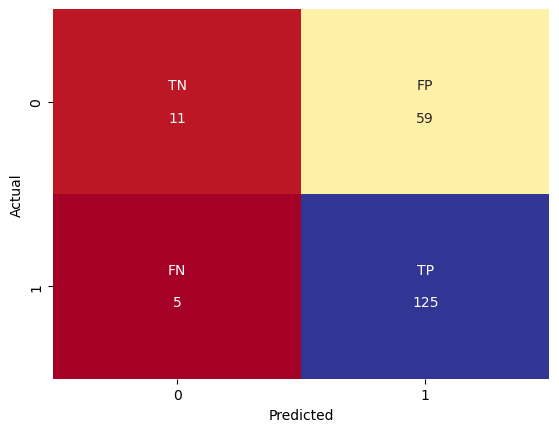

In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)
group_counts = [f"{value:0.0f}" for value in  cm.flatten()]
group_names = ['TN','FP', 'FN','TP']
labels = [f"{v1}\n\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.array(labels).reshape(2,2)
ax = sns.heatmap(cm, annot=labels, fmt="", cmap='RdYlBu',cbar=False)
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")